# MediCore Health Systems — Monitoring Data Analysis

## DTS206 A6: Data Visualisation & Analysis

This notebook analyses simulated operational monitoring data for
MediCore Health Systems. The dataset was supplied through the DTS206
Canvas module and is used in accordance with the assignment brief,
which permits the supplied simulated dataset as an alternative to
collecting a minimum of 30 days of live cloud-monitoring data.

The source dataset contains records for more than one simulated
organisation. Only virtual machines whose identifiers begin with
`medicore-` are retained for analysis. This ensures that all findings
presented in this notebook relate specifically to the MediCore
scenario.

Three visualisations are produced:

1. **CPU utilisation over time** — daily mean CPU utilisation, peak
   identification and a 7-day moving average are used to assess
   workload behaviour and compute headroom.
2. **Failed SSH login attempts by hour** — authentication failures are
   grouped by hour of day and analysed to identify the strongest
   three-hour concentration of failed access attempts.
3. **HTTP error-rate anomaly detection** — hourly HTTP error rates from
   the web and application tiers are evaluated using the interquartile
   range (IQR) method to identify abnormal operational behaviour.

The notebook uses Python with pandas, NumPy and Matplotlib.
Analytical techniques include time-series aggregation, moving
averages, peak-window analysis and IQR-based anomaly detection.

**Data source:** DTS206 Canvas simulated monitoring dataset.

> The dataset is simulated and is not represented as a direct export
> from the live MediCore AWS environment.

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


current_dir = Path.cwd()

if (current_dir / "analysis").is_dir():
    analysis_dir = current_dir / "analysis"
elif current_dir.name == "analysis":
    analysis_dir = current_dir
else:
    raise RuntimeError(
        "Run this notebook from the repository root or analysis folder."
    )

data_file = (
    analysis_dir
    / "data"
    / "medicore_monitoring_data.csv"
)

figure_1_path = analysis_dir / "figure-1-cpu-usage.png"
figure_2_path = analysis_dir / "figure-2-failed-logins.png"
figure_3_path = (
    analysis_dir
    / "figure-3-http-error-anomalies.png"
)

print(f"Analysis directory: {analysis_dir.resolve()}")
print(f"Dataset: {data_file.resolve()}")

Analysis directory: /home/bi94im/Documents/DTS206 Terraform Code/DTS206_Assignment/analysis
Dataset: /home/bi94im/Documents/DTS206 Terraform Code/DTS206_Assignment/analysis/data/medicore_monitoring_data.csv


In [32]:
if not data_file.exists():
    raise FileNotFoundError(
        f"Dataset not found: {data_file}"
    )

print("PASS: Monitoring dataset found.")

PASS: Monitoring dataset found.


In [33]:
source_df = pd.read_csv(data_file)

print(f"Rows loaded: {len(source_df):,}")
print(f"Columns loaded: {len(source_df.columns)}")

source_df.head()

Rows loaded: 10,080
Columns loaded: 22


,timestamp,date,day_of_month,hour,day_of_week,is_weekend,vm_id,vm_role,subnet,region,...,storage_used_gb,failed_ssh_logins,active_sessions,http_error_rate_pct,network_in_mb,network_out_mb,disk_iops,incident_flag,incident_type,incident_description
0,2025-06-01 00:00:00,2025-06-01,1,0,Sunday,1,medicore-web-vm-01,web,private,UK South,...,40.19,0,5,0.48,30.2,9.2,17,0,NaN,NaN
1,2025-06-01 00:00:00,2025-06-01,1,0,Sunday,1,medicore-web-vm-02,web,private,UK South,...,40.07,0,5,0.39,2.7,12.4,0,0,NaN,NaN
2,2025-06-01 00:00:00,2025-06-01,1,0,Sunday,1,medicore-app-vm-01,app,private,UK South,...,55.65,0,6,0.06,21.0,8.8,35,0,NaN,NaN
3,2025-06-01 00:00:00,2025-06-01,1,0,Sunday,1,medicore-app-vm-02,app,private,UK South,...,55.62,0,8,0.10,26.7,11.3,26,0,NaN,NaN
4,2025-06-01 00:00:00,2025-06-01,1,0,Sunday,1,medicore-app-vm-03,app,private,UK South,...,55.86,0,3,0.49,26.5,7.9,54,0,NaN,NaN


In [34]:
required_columns = {
    "timestamp",
    "date",
    "hour",
    "vm_id",
    "vm_role",
    "cpu_usage_pct",
    "memory_usage_pct",
    "failed_ssh_logins",
    "http_error_rate_pct",
    "incident_flag",
    "incident_type",
    "incident_description",
}

missing_columns = required_columns.difference(
    source_df.columns
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        f"{sorted(missing_columns)}"
    )

print("PASS: All required analysis columns are present.")

PASS: All required analysis columns are present.


In [35]:
df = source_df.copy()

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce",
)

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce",
)

numeric_columns = [
    "hour",
    "cpu_usage_pct",
    "memory_usage_pct",
    "storage_used_gb",
    "failed_ssh_logins",
    "active_sessions",
    "http_error_rate_pct",
    "network_in_mb",
    "network_out_mb",
    "disk_iops",
    "incident_flag",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )

medicore_df = df[
    df["vm_id"].str.startswith(
        "medicore-",
        na=False,
    )
].copy()

duplicate_count = medicore_df.duplicated().sum()

if duplicate_count > 0:
    medicore_df = medicore_df.drop_duplicates()

medicore_df = medicore_df.dropna(
    subset=[
        "timestamp",
        "date",
        "cpu_usage_pct",
        "failed_ssh_logins",
        "http_error_rate_pct",
    ]
)

medicore_df = medicore_df.sort_values(
    "timestamp"
).reset_index(drop=True)

print(f"Original rows: {len(source_df):,}")
print(f"MediCore rows: {len(medicore_df):,}")
print(f"Duplicate rows removed: {duplicate_count:,}")
print(
    "Monitoring period:",
    medicore_df["date"].min().date(),
    "to",
    medicore_df["date"].max().date(),
)
print(
    "Distinct monitoring days:",
    medicore_df["date"].nunique(),
)
print(
    "Distinct MediCore VMs:",
    medicore_df["vm_id"].nunique(),
)

Original rows: 10,080
MediCore rows: 5,760
Duplicate rows removed: 0
Monitoring period: 2025-06-01 to 2025-06-30
Distinct monitoring days: 30
Distinct MediCore VMs: 8


In [36]:
monitoring_days = medicore_df["date"].nunique()

if monitoring_days < 30:
    raise ValueError(
        "Fewer than 30 monitoring days were found."
    )

print(
    f"PASS: Dataset contains "
    f"{monitoring_days} monitoring days."
)

PASS: Dataset contains 30 monitoring days.


## Data Preparation and Quality Assessment

Before visualisation, the dataset was validated for required columns,
converted to appropriate date and numeric data types, filtered to
MediCore systems and checked for exact duplicate records.

The analysis retains the original source dataset unchanged. A separate
working DataFrame is used so that filtering and cleaning operations do
not modify the source data.

Temporal coverage, virtual-machine coverage and missing values are
also inspected before analytical techniques are applied. These checks
reduce the likelihood of interpreting malformed or unrelated records
as MediCore operational behaviour.

In [37]:
quality_columns = [
    "timestamp",
    "vm_id",
    "vm_role",
    "cpu_usage_pct",
    "memory_usage_pct",
    "failed_ssh_logins",
    "http_error_rate_pct",
    "incident_flag",
]

quality_summary = pd.DataFrame(
    {
        "data_type": (
            medicore_df[quality_columns]
            .dtypes
            .astype(str)
        ),
        "missing_values": (
            medicore_df[quality_columns]
            .isna()
            .sum()
        ),
        "unique_values": (
            medicore_df[quality_columns]
            .nunique()
        ),
    }
)

quality_summary

,data_type,missing_values,unique_values
timestamp,datetime64[us],0,720
vm_id,str,0,8
vm_role,str,0,4
cpu_usage_pct,float64,0,809
memory_usage_pct,float64,0,759
failed_ssh_logins,int64,0,35
http_error_rate_pct,float64,0,211
incident_flag,int64,0,2


In [38]:
print("Records by VM role:")
print(
    medicore_df["vm_role"]
    .value_counts()
    .sort_index()
)

print("\nMediCore virtual machines:")
print(
    medicore_df["vm_id"]
    .value_counts()
    .sort_index()
)

Records by VM role:
vm_role
app        2160
bastion     720
db         1440
web        1440
Name: count, dtype: int64

MediCore virtual machines:
vm_id
medicore-app-vm-01     720
medicore-app-vm-02     720
medicore-app-vm-03     720
medicore-bastion-01    720
medicore-db-primary    720
medicore-db-replica    720
medicore-web-vm-01     720
medicore-web-vm-02     720
Name: count, dtype: int64


# Figure 1 — CPU Utilisation Over Time

## Purpose

Figure 1 evaluates CPU utilisation across the simulated MediCore
environment. Individual monitoring observations are aggregated into a
daily mean CPU utilisation value.

A **7-day moving average** is then calculated to smooth short-term
variation and expose the longer-term workload trend. The day with the
highest mean utilisation is identified and annotated.

The 70% CPU threshold configured in the MediCore A3 Auto Scaling
design is included as an architectural reference. However, the chart
uses daily averages, whereas the scaling rule evaluates CPU over a
much shorter period. The chart therefore cannot prove that the
Auto Scaling threshold was never triggered.

**Data source:** DTS206 Canvas simulated monitoring dataset.

In [39]:
daily_cpu = (
    medicore_df
    .groupby(
        "date",
        as_index=False,
    )["cpu_usage_pct"]
    .mean()
    .sort_values("date")
)

daily_cpu["cpu_7_day_ma"] = (
    daily_cpu["cpu_usage_pct"]
    .rolling(
        window=7,
        min_periods=7,
    )
    .mean()
)

if len(daily_cpu) < 30:
    raise ValueError(
        "Figure 1 requires at least 30 data points."
    )

peak_cpu_index = (
    daily_cpu["cpu_usage_pct"].idxmax()
)

peak_cpu_date = daily_cpu.loc[
    peak_cpu_index,
    "date",
]

peak_cpu = daily_cpu.loc[
    peak_cpu_index,
    "cpu_usage_pct",
]

mean_cpu = daily_cpu[
    "cpu_usage_pct"
].mean()

median_cpu = daily_cpu[
    "cpu_usage_pct"
].median()

latest_cpu_ma = daily_cpu[
    "cpu_7_day_ma"
].dropna().iloc[-1]

print(
    f"Number of CPU data points: "
    f"{len(daily_cpu)}"
)

print(f"Mean CPU utilisation: {mean_cpu:.2f}%")
print(f"Median CPU utilisation: {median_cpu:.2f}%")
print(f"Peak CPU utilisation: {peak_cpu:.2f}%")
print(
    "Peak date:",
    peak_cpu_date.date(),
)
print(
    f"Latest 7-day moving average: "
    f"{latest_cpu_ma:.2f}%"
)

Number of CPU data points: 30
Mean CPU utilisation: 26.28%
Median CPU utilisation: 30.80%
Peak CPU utilisation: 33.92%
Peak date: 2025-06-09
Latest 7-day moving average: 26.54%


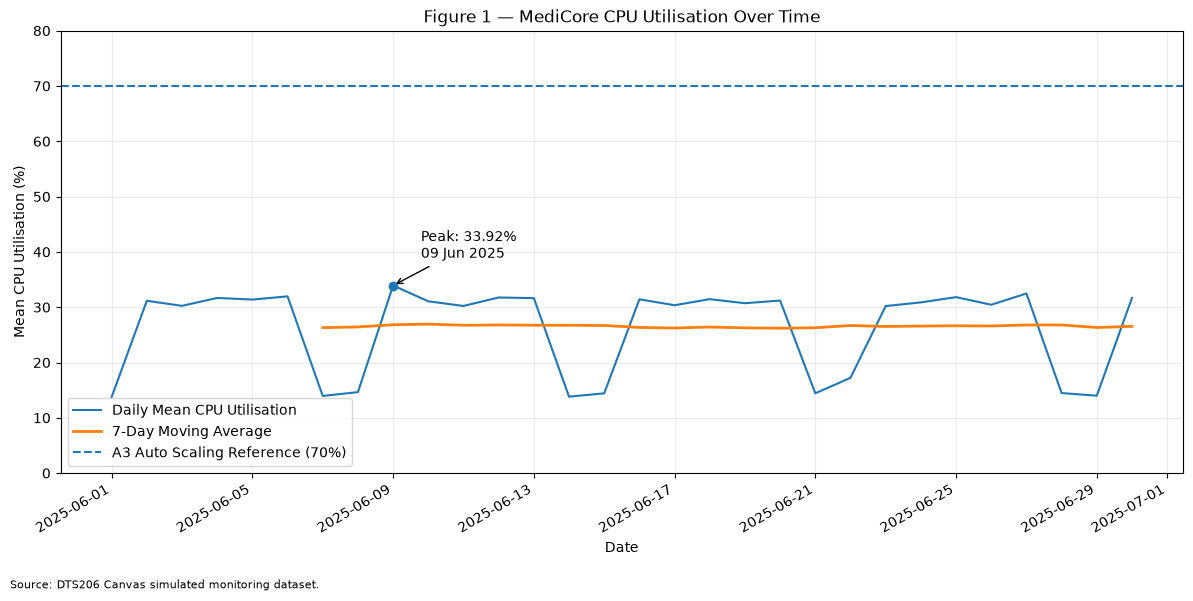

In [40]:
fig, ax = plt.subplots(
    figsize=(12, 6),
)

ax.plot(
    daily_cpu["date"],
    daily_cpu["cpu_usage_pct"],
    label="Daily Mean CPU Utilisation",
)

ax.plot(
    daily_cpu["date"],
    daily_cpu["cpu_7_day_ma"],
    linewidth=2,
    label="7-Day Moving Average",
)

ax.axhline(
    y=70,
    linestyle="--",
    label="A3 Auto Scaling Reference (70%)",
)

ax.scatter(
    peak_cpu_date,
    peak_cpu,
    zorder=5,
)

ax.annotate(
    (
        f"Peak: {peak_cpu:.2f}%\n"
        f"{peak_cpu_date:%d %b %Y}"
    ),
    xy=(
        peak_cpu_date,
        peak_cpu,
    ),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
    },
)

ax.set_title(
    "Figure 1 — MediCore CPU Utilisation Over Time"
)

ax.set_xlabel("Date")
ax.set_ylabel("Mean CPU Utilisation (%)")

ax.set_ylim(
    0,
    80,
)

ax.legend()

ax.grid(
    alpha=0.25,
)

fig.autofmt_xdate()

fig.text(
    0.01,
    0.01,
    (
        "Source: DTS206 Canvas simulated "
        "monitoring dataset."
    ),
    fontsize=8,
)

fig.tight_layout(
    rect=[0, 0.04, 1, 1]
)

fig.savefig(
    figure_1_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Figure 1 Findings

Figure 1 shows moderate CPU utilisation across the simulated MediCore
environment. Mean daily CPU utilisation was 26.28%, while the
median was 30.80%. The highest daily mean was 33.92% on
9 June 2025, and the latest 7-day moving average was 26.54%.

The 7-day moving average provides a clearer view of sustained demand
than individual daily observations and indicates that the environment
was not experiencing persistent CPU saturation during the monitoring
period. The observed daily averages also remained well below the
70% reference threshold used by the MediCore A3 Auto Scaling
design, suggesting that the deployed compute capacity provides
substantial general headroom for the simulated workload.

This comparison must be interpreted carefully because the A3 scaling
policy evaluates CPU over a short monitoring interval rather than a
daily average. Figure 1 therefore supports an assessment of general
capacity trends but cannot demonstrate that no short-duration scaling
event occurred.

**Data source:** DTS206 Canvas simulated monitoring dataset.

# Figure 2 — Failed SSH Login Attempts by Hour of Day

## Purpose

Figure 2 investigates whether failed SSH authentication attempts are
distributed evenly throughout the day or concentrated within a
particular time window.

Failed SSH attempts from all simulated MediCore virtual machines are
aggregated by hour of day. In addition to identifying the single peak
hour, a rolling three-hour total is calculated to locate the strongest
continuous three-hour concentration of failed authentication activity.

The detected period is then compared with the typical background
level outside that window. Failed logins are also aggregated by
individual VM and VM role to determine where the events were recorded.

**Data source:** DTS206 Canvas simulated monitoring dataset.

In [41]:
hourly_failed_logins = (
    medicore_df
    .groupby(
        "hour",
        as_index=False,
    )["failed_ssh_logins"]
    .sum()
    .set_index("hour")
    .reindex(
        range(24),
        fill_value=0,
    )
    .reset_index()
)

hourly_failed_logins[
    "three_hour_total"
] = (
    hourly_failed_logins[
        "failed_ssh_logins"
    ]
    .rolling(
        window=3,
        min_periods=3,
    )
    .sum()
)

peak_login_index = (
    hourly_failed_logins[
        "failed_ssh_logins"
    ].idxmax()
)

peak_login_hour = int(
    hourly_failed_logins.loc[
        peak_login_index,
        "hour",
    ]
)

peak_login_count = int(
    hourly_failed_logins.loc[
        peak_login_index,
        "failed_ssh_logins",
    ]
)

attack_end_index = (
    hourly_failed_logins[
        "three_hour_total"
    ].idxmax()
)

attack_end_hour = int(
    hourly_failed_logins.loc[
        attack_end_index,
        "hour",
    ]
)

attack_start_hour = attack_end_hour - 2

attack_window = hourly_failed_logins[
    hourly_failed_logins["hour"].between(
        attack_start_hour,
        attack_end_hour,
    )
]

attack_window_total = int(
    attack_window[
        "failed_ssh_logins"
    ].sum()
)

total_failed_logins = int(
    hourly_failed_logins[
        "failed_ssh_logins"
    ].sum()
)

attack_window_percentage = (
    attack_window_total
    / total_failed_logins
    * 100
)

background_logins = hourly_failed_logins[
    ~hourly_failed_logins["hour"].between(
        attack_start_hour,
        attack_end_hour,
    )
]

background_median = float(
    background_logins[
        "failed_ssh_logins"
    ].median()
)

peak_vs_background = (
    peak_login_count
    / background_median
)

print(
    f"Total failed SSH logins: "
    f"{total_failed_logins:,}"
)

print(
    f"Peak failed-login hour: "
    f"{peak_login_hour:02d}:00"
)

print(
    f"Peak-hour failures: "
    f"{peak_login_count:,}"
)

print(
    "Strongest three-hour window: "
    f"{attack_start_hour:02d}:00-"
    f"{attack_end_hour:02d}:59"
)

print(
    f"Failures in three-hour window: "
    f"{attack_window_total:,}"
)

print(
    f"Percentage in three-hour window: "
    f"{attack_window_percentage:.1f}%"
)

print(
    f"Background hourly median: "
    f"{background_median:.0f}"
)

print(
    f"Peak versus background median: "
    f"{peak_vs_background:.1f}x"
)

Total failed SSH logins: 5,096
Peak failed-login hour: 14:00
Peak-hour failures: 1,155
Strongest three-hour window: 14:00-16:59
Failures in three-hour window: 2,862
Percentage in three-hour window: 56.2%
Background hourly median: 99
Peak versus background median: 11.7x


In [42]:
failed_by_vm = (
    medicore_df
    .groupby(
        ["vm_id", "vm_role"],
        as_index=False,
    )["failed_ssh_logins"]
    .sum()
    .sort_values(
        "failed_ssh_logins",
        ascending=False,
    )
)

failed_by_role = (
    medicore_df
    .groupby(
        "vm_role",
        as_index=False,
    )["failed_ssh_logins"]
    .sum()
    .sort_values(
        "failed_ssh_logins",
        ascending=False,
    )
)

print("Failed SSH logins by VM:")
display(failed_by_vm)

print("Failed SSH logins by VM role:")
display(failed_by_role)

Failed SSH logins by VM:


,vm_id,vm_role,failed_ssh_logins
3,medicore-bastion-01,bastion,759
1,medicore-app-vm-02,app,680
7,medicore-web-vm-02,web,632
5,medicore-db-replica,db,631
2,medicore-app-vm-03,app,628
6,medicore-web-vm-01,web,627
0,medicore-app-vm-01,app,587
4,medicore-db-primary,db,552


Failed SSH logins by VM role:


,vm_role,failed_ssh_logins
0,app,1895
3,web,1259
2,db,1183
1,bastion,759


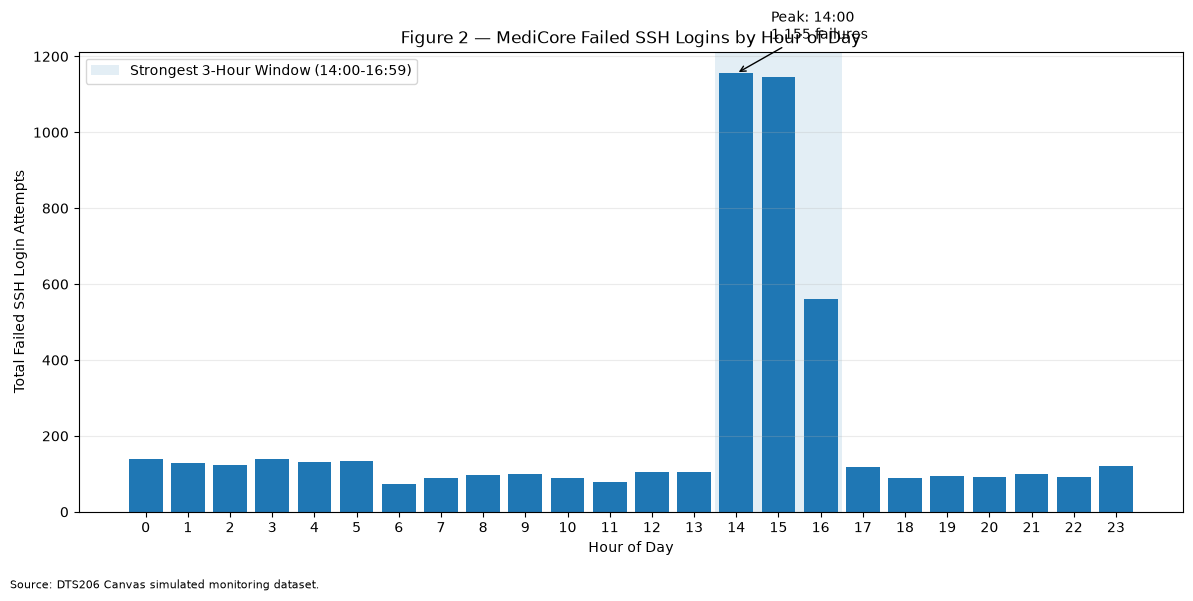

In [43]:
fig, ax = plt.subplots(
    figsize=(12, 6),
)

ax.bar(
    hourly_failed_logins["hour"],
    hourly_failed_logins[
        "failed_ssh_logins"
    ],
)

ax.axvspan(
    attack_start_hour - 0.5,
    attack_end_hour + 0.5,
    alpha=0.12,
    label=(
        "Strongest 3-Hour Window "
        f"({attack_start_hour:02d}:00-"
        f"{attack_end_hour:02d}:59)"
    ),
)

ax.annotate(
    (
        f"Peak: {peak_login_hour:02d}:00\n"
        f"{peak_login_count:,} failures"
    ),
    xy=(
        peak_login_hour,
        peak_login_count,
    ),
    xytext=(25, 25),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
    },
)

ax.set_title(
    "Figure 2 — MediCore Failed SSH Logins by Hour of Day"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Total Failed SSH Login Attempts")

ax.set_xticks(
    range(24)
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25,
)

fig.text(
    0.01,
    0.01,
    (
        "Source: DTS206 Canvas simulated "
        "monitoring dataset."
    ),
    fontsize=8,
)

fig.tight_layout(
    rect=[0, 0.04, 1, 1]
)

fig.savefig(
    figure_2_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Figure 2 Findings

Figure 2 shows a highly concentrated period of failed SSH
authentication activity within the simulated MediCore environment.
The largest hourly total occurred at 14:00, with 1,155 failed
attempts, followed by 1,145 at 15:00 and 562 at 16:00.
The automatically identified 14:00–16:59 window therefore contained
2,862 of the 5,096 failed SSH attempts, representing 56.2% of all
failures in the dataset.

Outside this three-hour window, the median hourly count was
approximately 99 failures. The 14:00 peak was therefore around
11.7 times the background median, indicating a substantial
departure from normal failed-authentication activity. The pattern is
consistent with automated scanning or brute-force behaviour in the
simulated environment, although failed login records alone cannot
prove malicious intent.

The MediCore bastion recorded the largest total for an individual
VM, with 759 failures. When systems were aggregated by role,
however, the application tier recorded 1,895 failures, followed by
the web tier with 1,259, database tier with 1,183, and bastion
with 759.

A suitable control is to prevent direct Internet SSH access to web,
application and database workloads. TCP port 22 should be restricted
to the bastion path, with administrative ingress to the bastion itself
limited to approved source addresses. Private-tier security groups
should permit SSH only from the bastion security group. Concentrated
authentication failures should also generate monitoring alerts and
investigation.

**Data source:** DTS206 Canvas simulated monitoring dataset.

### Risk Register Evidence

Figure 2 provides quantitative evidence for the B3 risk concerning
brute-force or unauthorised SSH access. The final B3 Risk Register
will reference this figure by its assigned Risk ID.

# Figure 3 — HTTP Error Rate Anomaly Detection

## Purpose

Figure 3 evaluates operational availability within the MediCore web
and application tiers. HTTP error-rate observations are restricted to
these roles because they represent the HTTP-facing services in the
simulated environment.

Measurements are aggregated by timestamp to produce an environment-
level hourly mean HTTP error rate. Anomalies are then identified using
the interquartile range (IQR) method.

The first quartile (Q1), third quartile (Q3) and interquartile range
are calculated, and observations above:

Q3 + 1.5 × IQR

are treated as unusually high HTTP error-rate observations.

IQR was selected because it provides a reproducible and data-driven
method for identifying unusually high values without inventing a
manual availability threshold. Detected anomalies are subsequently
compared with incident records in the source dataset.

**Data source:** DTS206 Canvas simulated monitoring dataset.

In [44]:
http_df = medicore_df[
    medicore_df["vm_role"].isin(
        ["web", "app"]
    )
].copy()

print(
    f"HTTP-facing records analysed: "
    f"{len(http_df):,}"
)

print(
    "HTTP-facing roles:",
    sorted(
        http_df["vm_role"]
        .dropna()
        .unique()
    ),
)

HTTP-facing records analysed: 3,600
HTTP-facing roles: ['app', 'web']


In [45]:
hourly_http_errors = (
    http_df
    .groupby(
        "timestamp",
        as_index=False,
    )
    .agg(
        http_error_rate_pct=(
            "http_error_rate_pct",
            "mean",
        ),
        incident_count=(
            "incident_flag",
            "sum",
        ),
    )
    .sort_values("timestamp")
)

print(
    f"Hourly HTTP data points: "
    f"{len(hourly_http_errors):,}"
)

hourly_http_errors.head()

Hourly HTTP data points: 720


,timestamp,http_error_rate_pct,incident_count
0,2025-06-01 00:00:00,0.304,0
1,2025-06-01 01:00:00,0.172,0
2,2025-06-01 02:00:00,0.284,0
3,2025-06-01 03:00:00,0.118,0
4,2025-06-01 04:00:00,0.190,0


In [46]:
q1 = hourly_http_errors[
    "http_error_rate_pct"
].quantile(0.25)

q3 = hourly_http_errors[
    "http_error_rate_pct"
].quantile(0.75)

iqr = q3 - q1

upper_anomaly_threshold = (
    q3 + (1.5 * iqr)
)

hourly_http_errors[
    "is_anomaly"
] = (
    hourly_http_errors[
        "http_error_rate_pct"
    ] > upper_anomaly_threshold
)

http_anomalies = hourly_http_errors[
    hourly_http_errors["is_anomaly"]
].copy()

print(f"Q1: {q1:.3f}%")
print(f"Q3: {q3:.3f}%")
print(f"IQR: {iqr:.3f}%")

print(
    f"Upper anomaly threshold: "
    f"{upper_anomaly_threshold:.3f}%"
)

print(
    f"Detected HTTP anomalies: "
    f"{len(http_anomalies):,}"
)

Q1: 0.228%
Q3: 0.757%
IQR: 0.529%
Upper anomaly threshold: 1.550%
Detected HTTP anomalies: 6


In [47]:
peak_http_index = (
    hourly_http_errors[
        "http_error_rate_pct"
    ].idxmax()
)

peak_http_timestamp = (
    hourly_http_errors.loc[
        peak_http_index,
        "timestamp",
    ]
)

peak_http_rate = float(
    hourly_http_errors.loc[
        peak_http_index,
        "http_error_rate_pct",
    ]
)

mean_http_rate = float(
    hourly_http_errors[
        "http_error_rate_pct"
    ].mean()
)

median_http_rate = float(
    hourly_http_errors[
        "http_error_rate_pct"
    ].median()
)

print(
    f"Mean hourly HTTP error rate: "
    f"{mean_http_rate:.3f}%"
)

print(
    f"Median hourly HTTP error rate: "
    f"{median_http_rate:.3f}%"
)

print(
    f"Peak hourly HTTP error rate: "
    f"{peak_http_rate:.3f}%"
)

print(
    "Peak timestamp:",
    peak_http_timestamp,
)

Mean hourly HTTP error rate: 0.533%
Median hourly HTTP error rate: 0.294%
Peak hourly HTTP error rate: 13.052%
Peak timestamp: 2025-06-09 15:00:00


In [48]:
incident_details = (
    http_df[
        http_df["incident_flag"] == 1
    ]
    .groupby(
        "timestamp",
        as_index=False,
    )
    .agg(
        incident_types=(
            "incident_type",
            lambda values: ", ".join(
                sorted(
                    set(
                        values
                        .dropna()
                        .astype(str)
                    )
                )
            ),
        ),
        incident_descriptions=(
            "incident_description",
            lambda values: " | ".join(
                sorted(
                    set(
                        values
                        .dropna()
                        .astype(str)
                    )
                )
            ),
        ),
    )
)

http_anomalies = http_anomalies.merge(
    incident_details,
    on="timestamp",
    how="left",
)

http_anomalies[
    [
        "timestamp",
        "http_error_rate_pct",
        "incident_count",
        "incident_types",
        "incident_descriptions",
    ]
]

,timestamp,http_error_rate_pct,incident_count,incident_types,incident_descriptions
0,2025-06-09 14:00:00,13.034,5,brute_force,Brute-force SSH attack — 847 attempts detected
1,2025-06-09 15:00:00,13.052,5,brute_force,Brute-force SSH attack — continued
2,2025-06-09 16:00:00,10.714,5,brute_force,Brute-force SSH attack — tail end
3,2025-06-15 02:00:00,3.034,5,maintenance,Scheduled maintenance — log rotation
4,2025-06-27 14:00:00,4.796,5,pen_test,Authorised penetration test — NCSC approved
5,2025-06-27 15:00:00,5.256,5,pen_test,Authorised penetration test — NCSC approved


In [49]:
anomaly_count = len(http_anomalies)

anomalies_with_incidents = int(
    (
        http_anomalies["incident_count"] > 0
    ).sum()
)

if anomaly_count > 0:
    anomaly_incident_percentage = (
        anomalies_with_incidents
        / anomaly_count
        * 100
    )
else:
    anomaly_incident_percentage = 0.0

print(
    f"Total HTTP anomalies: "
    f"{anomaly_count:,}"
)

print(
    f"Anomalies coinciding with incidents: "
    f"{anomalies_with_incidents:,}"
)

print(
    f"Anomaly/incident overlap: "
    f"{anomaly_incident_percentage:.1f}%"
)

Total HTTP anomalies: 6
Anomalies coinciding with incidents: 6
Anomaly/incident overlap: 100.0%


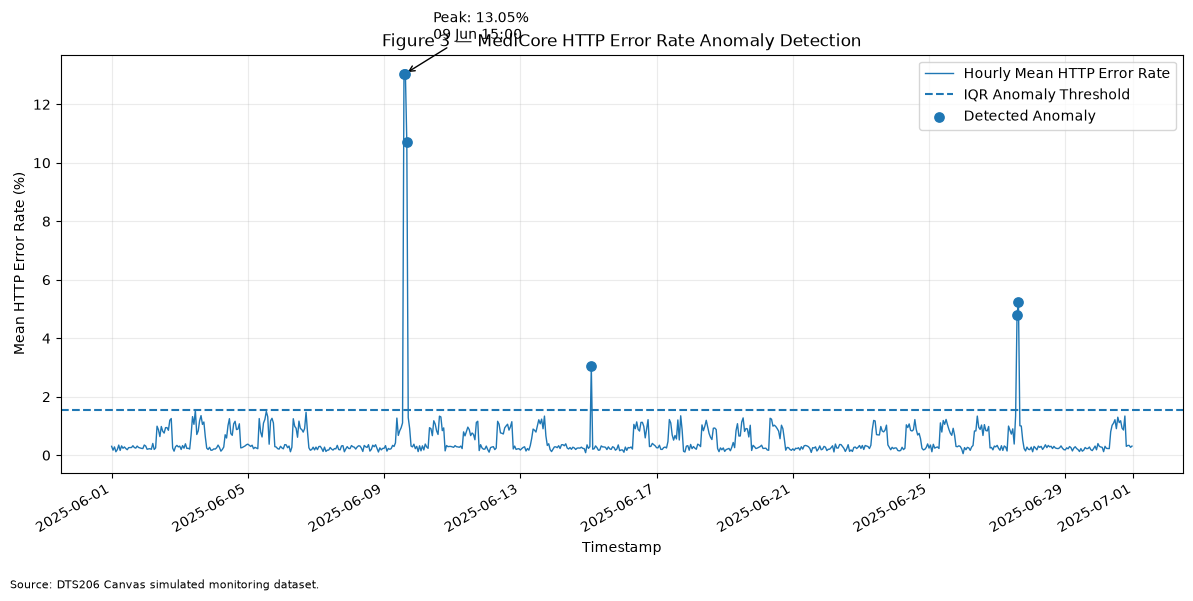

In [50]:
fig, ax = plt.subplots(
    figsize=(12, 6),
)

ax.plot(
    hourly_http_errors["timestamp"],
    hourly_http_errors[
        "http_error_rate_pct"
    ],
    linewidth=1,
    label="Hourly Mean HTTP Error Rate",
)

ax.axhline(
    y=upper_anomaly_threshold,
    linestyle="--",
    label="IQR Anomaly Threshold",
)

if not http_anomalies.empty:
    ax.scatter(
        http_anomalies["timestamp"],
        http_anomalies[
            "http_error_rate_pct"
        ],
        s=45,
        zorder=5,
        label="Detected Anomaly",
    )

ax.annotate(
    (
        f"Peak: {peak_http_rate:.2f}%\n"
        f"{peak_http_timestamp:%d %b %H:%M}"
    ),
    xy=(
        peak_http_timestamp,
        peak_http_rate,
    ),
    xytext=(20, 25),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
    },
)

ax.set_title(
    "Figure 3 — MediCore HTTP Error Rate Anomaly Detection"
)

ax.set_xlabel("Timestamp")
ax.set_ylabel("Mean HTTP Error Rate (%)")

ax.legend()

ax.grid(
    alpha=0.25,
)

fig.autofmt_xdate()

fig.text(
    0.01,
    0.01,
    (
        "Source: DTS206 Canvas simulated "
        "monitoring dataset."
    ),
    fontsize=8,
)

fig.tight_layout(
    rect=[0, 0.04, 1, 1]
)

fig.savefig(
    figure_3_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Figure 3 Findings

Figure 3 applies IQR-based anomaly detection to 720 hourly HTTP
error-rate observations from the simulated MediCore web and
application tiers. The normal distribution of error rates was
relatively low, with a median of 0.294% and a mean of 0.533%.
The calculated upper IQR anomaly threshold was 1.550%.

Only 6 of 720 hourly observations (0.83%) exceeded this threshold,
indicating that unusually high HTTP error rates were rare rather than
part of the normal operating pattern. The highest hourly mean error
rate was 13.052% at 15:00 on 9 June 2025, approximately 8.4
times the anomaly threshold and more than 44 times the median
hourly error rate.

All six statistically detected anomalies coincided with an incident
record in the simulated dataset. Three occurred during the labelled
brute-force event on 9 June, one during scheduled maintenance on
15 June, and two during the authorised penetration-test period on
27 June. This 100% overlap demonstrates that the IQR method
successfully identified periods already labelled as abnormal
operational events within the supplied dataset.

The result also shows why metric anomalies require contextual
investigation. Not every anomaly represents hostile activity:
maintenance and authorised testing produced abnormal service metrics
as well. Automated monitoring should therefore trigger investigation
rather than treating every threshold breach as a confirmed security
incident.

**Data source:** DTS206 Canvas simulated monitoring dataset.

### Risk Register Evidence

Figure 3 provides quantitative evidence for a B3 risk concerning
service degradation or availability incidents within the MediCore
environment. The detected HTTP error-rate anomalies demonstrate that
operational events can cause significant deviation from normal
service behaviour.

The final B3 Risk Register will reference this visualisation using the
appropriate assigned Risk ID.

## Cross-Visualisation Analysis

Figures 2 and 3 identify the same abnormal period on 9 June 2025.
Figure 2 shows the strongest three-hour concentration of failed SSH
authentication attempts between 14:00 and 16:59, while Figure 3
independently identifies HTTP error-rate anomalies at 14:00, 15:00
and 16:00 on the same date.

The source dataset labels these records as a simulated
brute_force incident. This provides a useful relationship between
security and availability monitoring: abnormal authentication
activity occurred at the same time as a substantial increase in HTTP
error rates.

This does not prove that failed SSH authentication directly caused
the HTTP errors. However, the temporal relationship demonstrates why
MediCore should correlate authentication, application and
infrastructure telemetry during incident investigation rather than
reviewing each monitoring source in isolation.

# Overall Interpretation

The simulated monitoring data indicates that the MediCore
environment generally operated with substantial compute headroom, but
also experienced clearly identifiable abnormal security and service
events. Figure 1 shows mean daily CPU utilisation of 26.28%, with
a maximum daily mean of 33.92% on 9 June 2025 and a latest 7-day
moving average of 26.54%. These values suggest that sustained CPU
demand was comfortably within available capacity during the observed
period. They also remain below the 70% reference point used by the A3
Auto Scaling design, although daily aggregation cannot rule out
short-duration threshold breaches.

The security data presents a different risk profile. Figure 2
identifies a concentrated failed-SSH window between 14:00 and
16:59, containing 2,862 of 5,096 failures (56.2%). The peak hour
alone contained 1,155 failed attempts, approximately 11.7 times
the background hourly median. This supports restricting SSH access to
controlled administrative paths and monitoring authentication
failures for abnormal concentrations.

Figure 3 demonstrates the value of analytical monitoring. Only
6 of 720 hourly HTTP observations exceeded the IQR anomaly
threshold, yet every detected anomaly coincided with a labelled event
in the simulated dataset. Most significantly, the HTTP anomalies on
9 June occurred during the same period as the failed-login spike in
Figure 2. This shows how correlated security and operational metrics
can help MediCore distinguish normal workload behaviour from events
requiring investigation.

Overall, the dataset suggests that routine compute capacity is
adequate, while access-control monitoring, event correlation and
service-availability detection should remain important operational
priorities.

# Reproducibility

This notebook is intended to be executed from either the repository
root or the /analysis directory.

Required Python packages are recorded in:

analysis/requirements.txt

The input dataset is stored in:

analysis/data/medicore-monitoring-simulated.csv

The notebook exports the following figures:

- figure-1-cpu-usage.png
- figure-2-failed-logins.png
- figure-3-http-error-anomalies.png

The original source CSV is not modified by the analysis. Data
cleaning and filtering are performed on a copied pandas DataFrame.